# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Renajwa Naylafasya
- **Email:** cdcc941d6x1938@student.devacademy.id
- **ID Dicoding:** CDCC941D6X1938

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Stasiun mana yang memiliki rata-rata tingkat polusi PM2.5 tertinggi dan terendah selama periode pengamatan (2013-2017)?
- Pertanyaan 2: Bagaimana tren bulanan konsentrasi PM2.5 di seluruh stasiun, dan pada bulan-bulan apa kualitas udara cenderung paling buruk?

## Import Semua Packages/Library yang Digunakan

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import calendar

## Data Wrangling

### Gathering Data

In [109]:
ao_df = pd.read_csv("https://raw.githubusercontent.com/Renaylaa/Proyek-Analisis-Data/refs/heads/main/data/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
ao_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [110]:
cp_df = pd.read_csv("https://raw.githubusercontent.com/Renaylaa/Proyek-Analisis-Data/refs/heads/main/data/PRSA_Data_Changping_20130301-20170228.csv")
cp_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


**Insight:**
- Pada tahap ini, digunakan dua dataset yang berasal dari PRSA (kualitas udara) pada tahun 2013 - 2017, mencakup dua lokasi yaitu daerah Aotizhongxin dan Changping.
- PM2.5, PM10, SO2, NO2, CO, O3: Indikator polusi udara
- TEMP, PRES, DEWP, RAIN, WSPM: Faktor meteorologi
- year, month, day, hour: Informasi waktu
- station: Lokasi pengamatan
- Aotizhongxin merepresentasikan area urban (perkotaan) dengan potensi aktivitas manusia yang tinggi.
- Changping merepresentasikan area suburban yang relatif lebih rendah aktivitas industrinya.

### Assessing Data

#### Menilai tabel ao_df

In [111]:
ao_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Memeriksa jumlah missing value:

In [112]:
ao_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,925
PM10,718
SO2,935
NO2,1023
CO,1776


Memeriksa jumlah duplikasi:

In [113]:
print("Jumlah duplikasi: ", ao_df.duplicated().sum())

Jumlah duplikasi:  0


In [114]:
ao_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


#### Menilai tabel cp_df

In [115]:
cp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


Memeriksa jumlah missing value:

In [116]:
cp_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,774
PM10,582
SO2,628
NO2,667
CO,1521


Memeriksa jumlah duplikasi:

In [117]:
print("Jumlah duplikasi: ", cp_df.duplicated().sum())

Jumlah duplikasi:  0


In [118]:
cp_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34290.000000,34482.000000,34436.000000,34397.000000,33543.000000,34460.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,71.099743,94.657871,14.958906,44.182086,1152.301345,57.940003,13.686111,1007.760278,1.505495,0.060366,1.853836
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.326926,83.441738,20.975331,29.519796,1103.056282,54.316674,11.365313,10.225664,13.822099,0.752899,1.309808
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,18.000000,34.000000,2.000000,22.000000,500.000000,15.636600,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,100.000000,131.000000,18.000000,60.358200,1400.000000,80.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,882.000000,999.000000,310.000000,226.000000,10000.000000,429.000000,41.400000,1036.500000,27.200000,52.100000,10.000000


**Insight:**
- Kedua dataset (Aotizhongxin dan Changping) memiliki jumlah data 35.064 baris, dan 18 kolom.
- ao_df memiliki cukup banyak missing value terutama pada kolom PM2.5, PM10, SO2, NO2, CO, dan O3.
- cp_df juga memiliki missing value yang dominan pada kolom PM2.5, PM10, SO2, NO2, CO, dan O3.
- Data polusi udara memiliki banyak nilai yang hilang, kemungkinan disebabkan oleh keterbatasan alat ukur atau gangguan selama proses pengumpulan data.
- Tidak ditemukan data duplikat pada kedua dataset, sehingga tidak diperlukan proses penghapusan duplikasi.
- Variasi nilai yang tinggi pada parameter polusi menunjukkan fluktuasi kualitas udara yang signifikan, yang dapat dipengaruhi oleh faktor waktu, cuaca, dan aktivitas manusia.


### Cleaning Data

#### Membersihkan tabel ao_df

Duplicate data

In [119]:
ao_df.duplicated().sum()

np.int64(0)

In [120]:
ao_df.drop_duplicates(inplace=True)

In [121]:
print("Jumlah duplikasi: ", ao_df.duplicated().sum())

Jumlah duplikasi:  0


Missing values

In [122]:
ao_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,925
PM10,718
SO2,935
NO2,1023
CO,1776


In [123]:
ao_df[ao_df['PM2.5'].isna()]

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
1509,1510,2013,5,2,21,NaN,183.0,63.0000,93.0000,1200.0,38.0000,18.5,1006.1,6.0,0.0,SE,2.8,Aotizhongxin
1837,1838,2013,5,16,13,NaN,98.0,46.0000,35.0000,600.0,166.0000,26.1,1009.9,10.7,0.0,SW,2.7,Aotizhongxin
2368,2369,2013,6,7,16,NaN,137.0,12.0000,74.0000,2500.0,8.0000,20.7,1002.4,19.4,0.0,NNE,0.8,Aotizhongxin
2785,2786,2013,6,25,1,NaN,35.0,3.1416,35.1063,NaN,60.6186,20.8,996.5,20.5,0.0,NE,0.2,Aotizhongxin
2808,2809,2013,6,26,0,NaN,183.0,64.2600,40.0335,NaN,NaN,21.7,993.0,21.2,0.0,NNW,0.4,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34880,34881,2017,2,21,8,NaN,NaN,NaN,NaN,NaN,NaN,-0.3,1028.8,-15.8,0.0,SSE,1.0,Aotizhongxin
34883,34884,2017,2,21,11,NaN,NaN,NaN,NaN,NaN,NaN,1.3,1028.0,-16.1,0.0,S,1.5,Aotizhongxin
34885,34886,2017,2,21,13,NaN,NaN,NaN,NaN,NaN,NaN,-2.1,1027.4,-4.1,0.7,WSW,3.2,Aotizhongxin
35028,35029,2017,2,27,12,NaN,NaN,NaN,NaN,NaN,NaN,12.1,1017.3,-5.4,0.0,SSW,1.2,Aotizhongxin


Mengisi missing value pada kolom numerik

In [124]:
cols_to_fix = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
ao_df[cols_to_fix] = ao_df[cols_to_fix].interpolate(method='linear')

Mengisi missing value pada kolom kategorikal

In [125]:
ao_df['wd'] = ao_df['wd'].fillna(method='ffill')

/tmp/ipykernel_4741/1256037981.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ao_df['wd'] = ao_df['wd'].fillna(method='ffill')


In [126]:
ao_df.fillna(method='bfill', inplace=True)

/tmp/ipykernel_4741/3391540428.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ao_df.fillna(method='bfill', inplace=True)


In [127]:
print(ao_df.isna().sum())

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64


#### Membersihkan tabel data cp_df

Duplicate data

In [128]:
cp_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,774
PM10,582
SO2,628
NO2,667
CO,1521


Missing values

In [129]:
print(cp_df.isna().sum())

No            0
year          0
month         0
day           0
hour          0
PM2.5       774
PM10        582
SO2         628
NO2         667
CO         1521
O3          604
TEMP         53
PRES         50
DEWP         53
RAIN         51
wd          140
WSPM         43
station       0
dtype: int64


Mengisi missing value pada kolom numerikal

In [130]:
cols_to_fix = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
cp_df[cols_to_fix] = cp_df[cols_to_fix].interpolate(method='linear')

Mengisi missing value pada kolom kategorikal

In [131]:
cp_df['wd'] = cp_df['wd'].fillna(method='ffill')

/tmp/ipykernel_4741/3491250986.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cp_df['wd'] = cp_df['wd'].fillna(method='ffill')


In [132]:
cp_df.fillna(method='bfill', inplace=True)

/tmp/ipykernel_4741/3179928741.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cp_df.fillna(method='bfill', inplace=True)


In [133]:
cp_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


**Insight:**
- Tidak ditemukan data duplikat pada kedua dataset (ao_df dan cp_df).
- Pada kolom numerik, dilakukan dengan metode interpolasi linear yang digunakan untuk memperkirakan nilai yang hilang berdasarkan pola data sebelum dan sesudah.
- Pada kolom kategorikal, dilakukan dengan metode forward fill, yang dimana nilai arah angin yang hilang diisi dengan nilai sebelumnya, dengan asumsi kalau arah mata angin tidak akan berubah secara signifikan dalam waktu yang dekat.
- Dilakukan penyempurnaan dengan metode backward fill untuk mengisi sisa missing value yang tidak terjangkau.
- Seluruh missing value berhasil ditangani dengan baik.

## Exploratory Data Analysis (EDA)

### Explore ao_df

In [134]:
ao_df.sample(5)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
4479,4480,2013,9,3,15,100.0,117.0,15.0,40.0,1100.0,189.0,28.1,1008.2,17.9,0.0,SSE,2.4,Aotizhongxin
260,261,2013,3,11,20,156.0,214.0,103.0,116.0,1899.0,47.0,9.8,1010.4,-2.8,0.0,SSE,1.3,Aotizhongxin
18516,18517,2015,4,11,12,136.0,136.0,20.0,31.0,1700.0,125.0,17.1,1015.8,6.9,0.0,SE,3.0,Aotizhongxin
8005,8006,2014,1,28,13,65.0,112.0,37.0,31.0,900.0,50.0,4.8,1021.3,-8.0,0.0,SW,4.4,Aotizhongxin
2225,2226,2013,6,1,17,17.0,39.0,3.0,26.0,200.0,139.0,27.9,1001.1,7.2,0.0,NNE,2.7,Aotizhongxin


In [135]:
ao_df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064,35064.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Aotizhongxin
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5161,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.540623,110.210033,17.459251,59.074106,1264.692405,55.328626,13.581414,1011.851650,3.120296,0.067383,NaN,1.708577,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.956401,95.262531,22.702284,37.000918,1239.411826,57.327470,11.400426,10.404517,13.690314,0.909798,NaN,1.204180,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,NaN,1.400000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,154.000000,22.000000,81.000000,1500.000000,81.000000,23.300000,1020.100000,15.600000,0.000000,NaN,2.200000,NaN


In [136]:
print("Aotizhongxin No is unique:", ao_df.No.is_unique)

Aotizhongxin No is unique: True


In [137]:
print("Jumlah duplikasi: ", ao_df.duplicated().sum())

Jumlah duplikasi:  0


Statistik PM2.5 dan suhu (TEMP) per tahun:

In [138]:
ao_df.groupby(by="year").agg({
    "PM2.5": ["max", "min", "mean", "std"],
    "TEMP": ["max", "min", "mean", "std"]
})

PM2.5                              TEMP                            
        max  min       mean         std   max   min       mean        std
year                                                                     
2013  665.0  3.0  82.439202   73.714513  37.9  -9.4  15.497740  10.303748
2014  584.0  3.0  89.747603   82.994033  40.5 -12.2  13.878128  11.257834
2015  657.0  3.0  81.831724   85.115005  38.8 -10.0  13.474687  11.344323
2016  898.0  3.0  74.236680   76.993233  37.3 -16.8  13.871962  11.909310
2017  713.0  3.0  94.379237  114.330923  15.9  -9.7   0.664779   4.579472

Statistik PM2.5 dan suhu (TEMP) per bulan (pola musiman):

In [139]:
ao_df.groupby(by="month").agg({
    "PM2.5": ["max", "min", "mean", "std"],
    "TEMP": ["mean"]
})

PM2.5                                    TEMP
         max  min        mean         std       mean
month                                               
1      713.0  3.0   92.414180  101.285609  -1.634114
2      898.0  3.0   87.214049  102.417556   1.299502
3      463.0  3.0   99.936761   90.654900   8.403951
4      403.0  3.0   78.473785   57.638363  15.309271
5      665.0  3.0   67.337399   53.160310  21.419657
6      510.0  3.0   71.348611   59.519173  24.561424
7      280.0  3.0   74.890625   52.913913  27.195262
8      260.0  3.0   55.851815   43.036165  26.715121
9      321.0  3.0   64.400104   54.918122  20.916237
10     446.0  3.0   97.224294   95.290598  13.510233
11     619.0  3.0   98.544132   94.100314   4.683438
12     657.0  3.0  102.705141  117.006141  -0.133031

Analisis PM2.5 berdasarkan arah angin (wd):

In [140]:
ao_df.groupby(by="wd")['PM2.5'].mean().sort_values(ascending=False)

,PM2.5
wd,
E,108.087880
ESE,105.937114
ENE,104.804426
SE,99.832076
SSE,97.932937
S,94.362386
NE,93.448003
SSW,86.522083
SW,79.723369


Analisis PM2.5 berdasarkan jam (hour):

In [141]:
ao_df.groupby(by="hour")['PM2.5'].mean().sort_values(ascending=False)

,PM2.5
hour,
1,92.252360
0,91.947362
23,91.527238
2,91.479032
22,90.760571
21,88.968852
3,88.447364
20,86.257986
4,85.127424


### Explore cp_df

In [142]:
cp_df.sample(5)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
17422,17423,2015,2,24,22,204.0,260.0,28.0,56.0,2400.0,38.0,2.8,1006.6,-5.8,0.0,WNW,1.0,Changping
27628,27629,2016,4,25,4,63.0,112.0,5.0,24.0,400.0,32.0,16.2,1000.7,10.1,0.0,NE,0.9,Changping
16349,16350,2015,1,11,5,23.0,39.0,11.0,53.0,900.0,13.0,-1.0,1022.0,-13.6,0.0,WNW,0.9,Changping
1487,1488,2013,5,1,23,52.0,98.0,16.0,43.0,700.0,73.0,16.7,1004.2,0.3,0.0,ESE,1.2,Changping
14812,14813,2014,11,8,4,51.0,60.0,4.0,43.0,1300.0,8.0,0.2,1019.0,-5.0,0.0,NNE,0.5,Changping


In [143]:
cp_df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064,35064.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NNW,NaN,Changping
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4790,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,70.986438,94.788575,14.943066,44.206153,1156.990246,57.976253,13.671605,1007.771151,1.486924,0.060293,NaN,1.854871,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.397726,83.928515,21.012174,29.502709,1122.612745,54.258719,11.367457,10.226075,13.828895,0.752357,NaN,1.310748,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,18.000000,34.000000,2.000000,22.000000,500.000000,16.000000,3.400000,999.300000,-10.300000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.600000,1007.400000,1.700000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,100.000000,131.000000,18.000000,60.000000,1400.000000,80.000000,23.300000,1016.000000,14.200000,0.000000,NaN,2.300000,NaN


In [144]:
print("Changpin No is unique:", cp_df.No.is_unique)

Changpin No is unique: True


In [145]:
print("Jumlah duplikasi:", cp_df.duplicated().sum())

Jumlah duplikasi: 0


Statistik PM2.5 dan suhu (TEMP) per tahun:

In [146]:
cp_df.groupby(by="year").agg({
    "PM2.5": ["max", "min", "mean", "std"],
    "TEMP": ["max", "min", "mean", "std"]
})

PM2.5                             TEMP                                 
        max  min       mean        std   max        min       mean        std
year                                                                         
2013  443.0  2.0  72.393246  68.478578  37.9  -9.600000  15.961397  10.102414
2014  581.0  3.0  79.881998  78.983081  41.4 -10.900000  14.172511  11.431695
2015  500.0  3.0  68.832608  69.545412  39.2 -10.300000  13.567626  11.208193
2016  882.0  3.0  61.665699  65.341786  38.1 -16.600000  13.499471  11.757835
2017  662.0  3.0  79.802966  96.660393  15.6  -9.966667   0.407973   4.756118

Statistik PM2.5 dan suhu (TEMP) per bulan (pola musiman):

In [147]:
cp_df.groupby(by="month").agg({
    "PM2.5": ["max", "min", "mean", "std"],
    "TEMP": ["mean"]
})

PM2.5                                  TEMP
         max  min       mean        std       mean
month                                             
1      662.0  3.0  84.348757  89.943560  -1.539167
2      882.0  3.0  81.794063  94.175258   1.251549
3      443.0  3.0  84.001428  82.155087   8.398068
4      510.0  2.0  70.376389  58.215915  15.437361
5      381.0  3.0  60.602050  51.740847  21.616465
6      500.0  2.0  59.516632  56.265171  24.705313
7      540.0  3.0  62.473790  53.295765  27.247513
8      268.0  3.0  46.796976  40.977392  26.686895
9      304.0  3.0  55.301389  52.636758  20.744407
10     404.0  3.0  81.100302  83.453459  13.575558
11     347.0  3.0  78.482951  69.974545   5.097917
12     596.0  3.0  87.347446  94.439639   0.100067

Analisis PM2.5 berdasarkan arah angin (wd):

In [148]:
cp_df.groupby(by="wd")['PM2.5'].mean().sort_values(ascending=False)

,PM2.5
wd,
ESE,98.532103
E,93.860771
SE,86.888340
ENE,84.752160
SSE,81.929282
SSW,80.525094
SW,77.910600
S,76.197414
WSW,70.884779


Analisis PM2.5 berdasarkan jam (hour):

In [149]:
cp_df.groupby(by="hour")['PM2.5'].mean().sort_values(ascending=False)

,PM2.5
hour,
21,77.940782
20,77.864936
11,75.920871
10,75.657084
19,75.573439
22,75.364706
12,74.757586
23,73.371268
0,72.773445


### Explore ao_df dan cp_df

In [150]:
main_df = pd.concat([ao_df, cp_df], ignore_index=True)

main_df.to_csv("all_data.csv", index=False)

print("Informasi dataset gabungan:")
main_df.info()

print("\nJumlah data per stasiun:")
print(main_df['station'].value_counts())

Informasi dataset gabungan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       70128 non-null  int64  
 1   year     70128 non-null  int64  
 2   month    70128 non-null  int64  
 3   day      70128 non-null  int64  
 4   hour     70128 non-null  int64  
 5   PM2.5    70128 non-null  float64
 6   PM10     70128 non-null  float64
 7   SO2      70128 non-null  float64
 8   NO2      70128 non-null  float64
 9   CO       70128 non-null  float64
 10  O3       70128 non-null  float64
 11  TEMP     70128 non-null  float64
 12  PRES     70128 non-null  float64
 13  DEWP     70128 non-null  float64
 14  RAIN     70128 non-null  float64
 15  wd       70128 non-null  object 
 16  WSPM     70128 non-null  float64
 17  station  70128 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 9.6+ MB

Jumlah data per stasiun:
station
Aotizh

In [151]:
main_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [152]:
main_df.describe(include="all")

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128,70128.000000,70128
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Aotizhongxin
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6898,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,76.763530,102.499304,16.201158,51.640129,1210.841326,56.652439,13.626509,1009.811400,2.303610,0.063838,NaN,1.781724,NaN
std,10122.177085,1.177205,3.448728,8.800155,6.922236,77.539869,90.104461,21.909555,34.278094,1183.672491,55.829488,11.383962,10.515439,13.783897,0.834799,NaN,1.260708,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.800000,982.400000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,25.000000,500.000000,11.000000,3.300000,1001.200000,-9.200000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,52.000000,79.000000,8.000000,44.000000,800.000000,44.000000,14.600000,1009.400000,2.800000,0.000000,NaN,1.400000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,107.000000,142.000000,20.000000,71.000000,1500.000000,80.000000,23.300000,1018.100000,14.900000,0.000000,NaN,2.300000,NaN


In [153]:
main_df.groupby(by="station").agg({
    "PM2.5": ["max", "min", "mean", "std"]
})

PM2.5                           
                max  min       mean        std
station                                       
Aotizhongxin  898.0  3.0  82.540623  81.956401
Changping     882.0  2.0  70.986438  72.397726

In [154]:
main_df.groupby(by="month").agg({
    "PM2.5": ["max", "min", "mean", "std"]
})
main_df.groupby(by="month")['PM2.5'].mean().sort_values(ascending=False)

,PM2.5
month,
12,95.026294
3,91.969094
10,89.162298
11,88.513542
1,88.381468
2,84.504056
4,74.425087
7,68.682208
6,65.432622


In [155]:
main_df.groupby(by="station").agg({
    "TEMP": ["max", "min", "mean"]
})

TEMP                 
               max   min       mean
station                            
Aotizhongxin  40.5 -16.8  13.581414
Changping     41.4 -16.6  13.671605

**Insight:**
- Data sudah bersih dari missing value dan duplikasi data.
- Kualitas udara tidak stabil tiap tahun, kemungkinan dipengaruhi faktor eksternal seperti kebijakan, industri, atau cuaca.
- Dari hasil pola musiman (per bulan), terdapat hasil pola yang jelas, yaitu jika suhu rendah, maka polusi tinggi, dan jika suhu tinggi, maka polusi rendah.
- PM2.5 lebih tinggi di jam-jam tertentu, kemungkinan dipengaruhi oleh jam sibuk, dan aktivitas harian manusia.
- Beberapa arah angin mengahsilkan PM2.5 lebih tinggi, yang kemungkinan dipengaruhi arah angin yang membawa polusi dari sumber tertentu.
- Dari suhu juga terlihat pola, jika suhu rendah maka PM2.5 tinggi, sedangkan jika suhu tinggi maka PM2.5 rendah.
- Setiap lokasi punya karakteristik polusi sendiri.
- Dari gabungan dataset (ao_df dan cp_df), total data menjadi 70.128, dengan total kolom 18.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Stasiun mana yang memiliki rata-rata tingkat polusi PM2.5 tertinggi dan terendah selama periode pengamatan (2013-2017)?

In [156]:
main_df.sample(5)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
15461,15462,2014,12,5,5,5.0,7.0,9.0,16.0,500.0,43.0000,-4.9,1030.0,-21.1,0.0,NNE,1.7,Aotizhongxin
55860,20797,2015,7,15,12,27.0,50.0,2.0,28.0,400.0,66.0000,27.5,997.9,16.8,0.0,NE,1.3,Changping
58481,23418,2015,11,1,17,47.0,77.0,6.0,68.0,600.0,52.0000,15.8,1011.1,-2.2,0.0,E,1.6,Changping
25082,25083,2016,1,10,2,82.0,86.0,29.0,86.0,2600.0,9.0000,-5.8,1022.8,-12.3,0.0,NNE,1.0,Aotizhongxin
41439,6376,2013,11,21,15,72.0,83.0,49.0,47.0,1000.0,28.0602,11.6,1015.2,-7.8,0.0,SSW,1.6,Changping


In [157]:
pm25_df = main_df.groupby("station")["PM2.5"].mean().sort_values(ascending=False).reset_index()
pm25_df.head()

,station,PM2.5
0,Aotizhongxin,82.540623
1,Changping,70.986438


/tmp/ipykernel_4741/670212505.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PM2.5", y="station", data=top5_station, palette=colors, ax=ax[0])
/tmp/ipykernel_4741/670212505.py:11: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(x="PM2.5", y="station", data=top5_station, palette=colors, ax=ax[0])
/tmp/ipykernel_4741/670212505.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PM2.5", y="station", data=bottom5_station, palette=colors, ax=ax[1])
/tmp/ipykernel_4741/670212505.py:16: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(x="PM2.5", y="station", data=bot

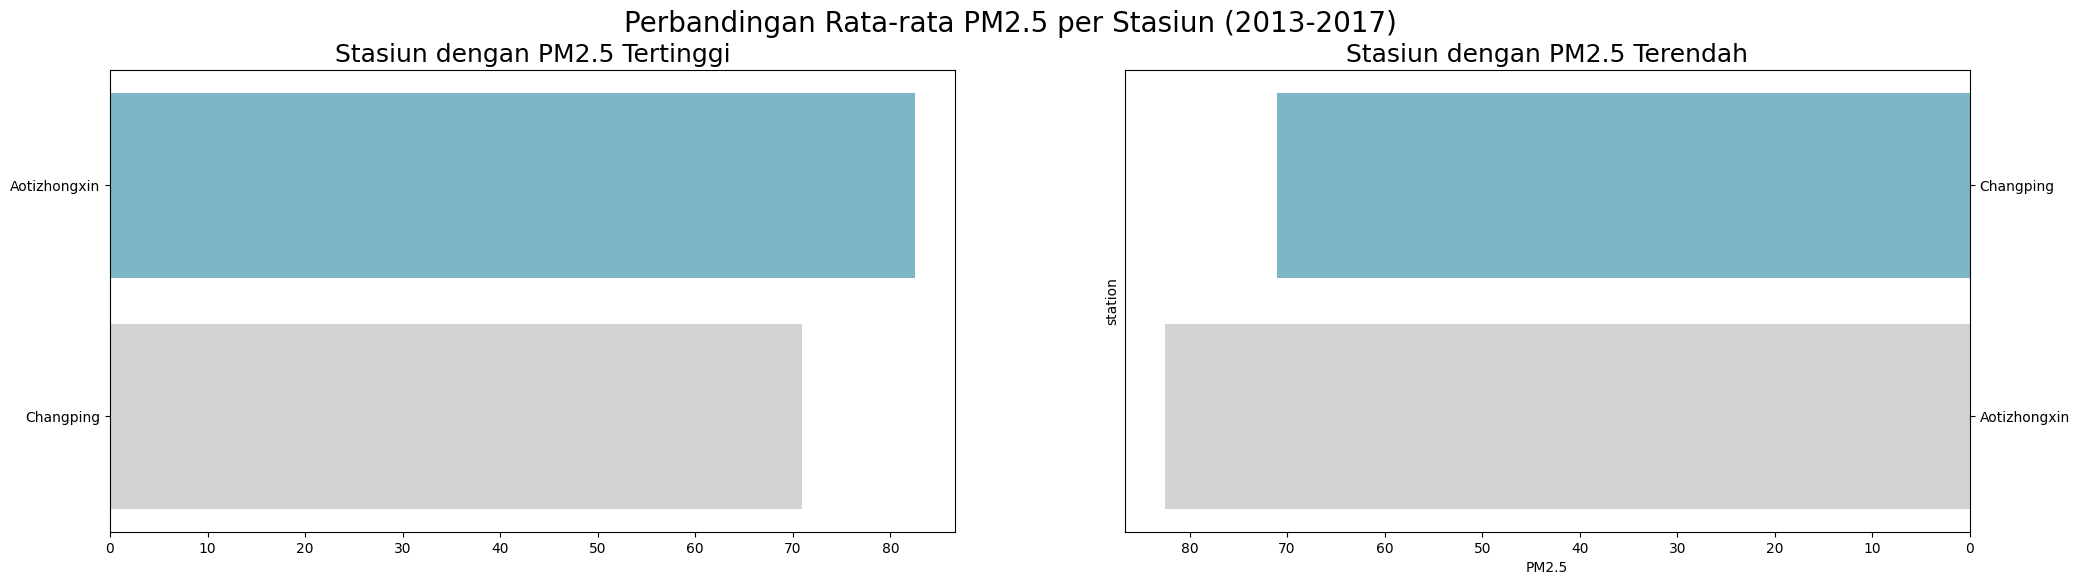

In [158]:
top5_station = pm25_df.head(5)
bottom5_station = pm25_df.sort_values(by="PM2.5", ascending=True).head(5)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="PM2.5", y="station", data=top5_station, palette=colors, ax=ax[0])
ax[0].set_title("Stasiun dengan PM2.5 Tertinggi", fontsize=18)
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)

sns.barplot(x="PM2.5", y="station", data=bottom5_station, palette=colors, ax=ax[1])
ax[1].set_title("Stasiun dengan PM2.5 Terendah", fontsize=18)
ax[1].invert_xaxis()
ax[1].yaxis.tick_right()

plt.suptitle("Perbandingan Rata-rata PM2.5 per Stasiun (2013-2017)", fontsize=20)
plt.show()

### Pertanyaan 2: Bagaimana tren bulanan konsentrasi PM2.5 di seluruh stasiun, dan pada bulan-bulan apa kualitas udara cenderung paling buruk?

In [159]:
main_df["date"] = pd.to_datetime(main_df[["year", "month", "day"]])

In [160]:
tabel_bulanan = main_df.groupby("month")["PM2.5"] \
    .mean() \
    .reset_index()

tabel_bulanan["Bulan"] = tabel_bulanan["month"].apply(lambda x: calendar.month_name[x])

tabel_bulanan = tabel_bulanan[["Bulan", "PM2.5"]]

tabel_bulanan = tabel_bulanan.sort_values(by="PM2.5", ascending=False)

tabel_bulanan

,Bulan,PM2.5
11,December,95.026294
2,March,91.969094
9,October,89.162298
10,November,88.513542
0,January,88.381468
1,February,84.504056
3,April,74.425087
6,July,68.682208
5,June,65.432622
4,May,63.969724


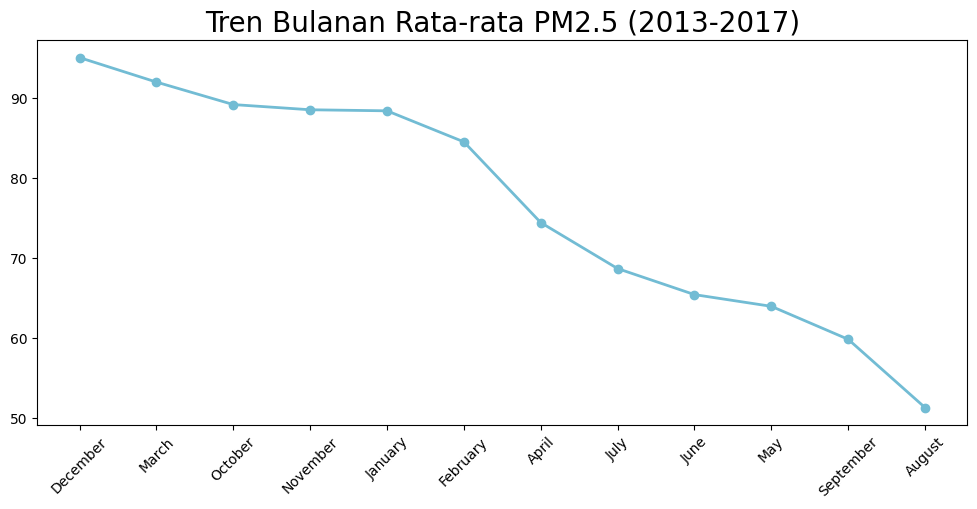

In [161]:
plt.figure(figsize=(12, 5))

plt.plot(
    tabel_bulanan["Bulan"],
    tabel_bulanan["PM2.5"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Tren Bulanan Rata-rata PM2.5 (2013-2017)", fontsize=20)
plt.xticks(rotation=45)
plt.yticks(fontsize=10)
plt.show()

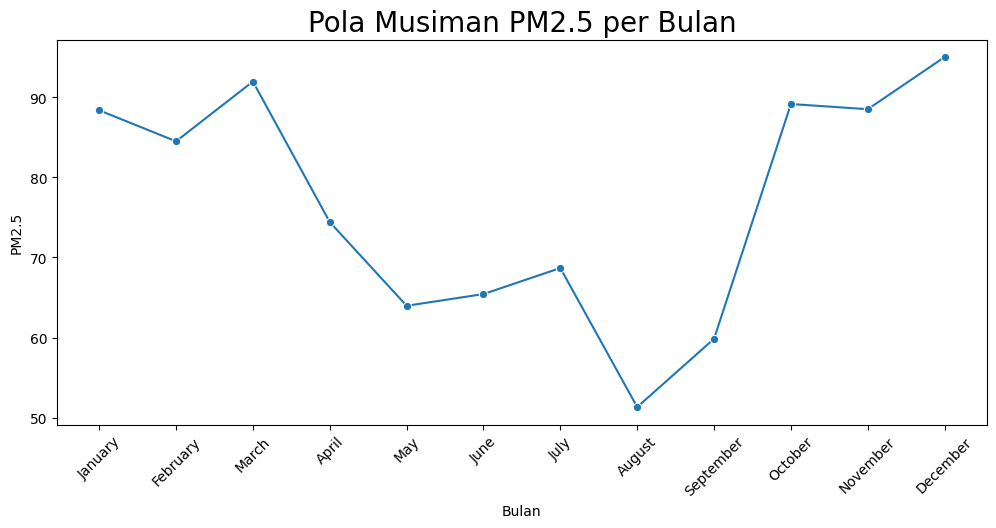

In [162]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

tabel_bulanan["Bulan"] = pd.Categorical(tabel_bulanan["Bulan"], categories=month_order, ordered=True)
tabel_bulanan = tabel_bulanan.sort_values("Bulan")

plt.figure(figsize=(12, 5))
sns.lineplot(data=tabel_bulanan, x="Bulan", y="PM2.5", marker="o")

plt.title("Pola Musiman PM2.5 per Bulan", fontsize=20)
plt.xticks(rotation=45)
plt.show()

In [163]:
worst_month = tabel_bulanan.sort_values(by="PM2.5", ascending=False).head(1)
best_month = tabel_bulanan.sort_values(by="PM2.5", ascending=True).head(1)

print("Bulan terburuk:")
print(worst_month)

print("\nBulan terbaik:")
print(best_month)

Bulan terburuk:
       Bulan      PM2.5
11  December  95.026294

Bulan terbaik:
    Bulan      PM2.5
7  August  51.324395


**Insight:**

- **Pertanyaan 1: Stasiun mana yang memiliki rata-rata tingkat polusi PM2.5 tertinggi dan terendah selama periode pengamatan (2013-2017)?**


1.   Grafik menunjukkan adanya perbedaan rata-rata PM2.5 antar stasiun.
2.   Aotizhongxin memiliki nilai rata-rata tingkat polusi lebih tinggi.
3. Changping memiliki nilai rata-rata tingkat polusi lebih rendah.
4. Stasiun dengan PM2.5 tertinggi dapat berarti perlu perhatian lebih karena termasuk area rawan polusi.
5. Stasiun dengn PM2.5 terendah dapat berarti bisa dijadikan benchmark kualitas udara lebih baik.


- **Pertanyaan 2: Bagaimana tren bulanan konsentrasi PM2.5 di seluruh stasiun, dan pada bulan-bulan apa kualitas udara cenderung paling buruk?**


1.   Terlihat pola naik-turun yang konsisten tiap bulan, menunjukan terdapat faktor seasonality.
2. Bulan dengan polusi terburuk ada pada bulan desember, sedangkan polusi terbaik ada pada bulan agustus.
3.   Terdapat pola suhu, yaitu saat musim dingin polusi lebih tinggi, dan saat musim panas, polusi cenderung lebih rendah.
4. Polusi udara dapat diprediksi berdasarkan bulan.
5. Periode risiko polusi tinggi ada pada akhir tahun, sedangkan yang relatif aman ada pada pertengahan tahun.



## Analisis Lanjutan (Opsional)

### Geospatial Analysis

Rata-rata PM2.5 per stasiun:

In [164]:
geo_df = main_df.groupby("station")["PM2.5"].mean().reset_index()
geo_df.rename(columns={"PM2.5": "avg_PM2.5"}, inplace=True)

geo_df.head()

,station,avg_PM2.5
0,Aotizhongxin,82.540623
1,Changping,70.986438


Koordinat:

In [165]:
station_coords = {
    "Aotizhongxin": [39.982, 116.397],
    "Changping": [40.218, 116.231]
}

geo_df["lat"] = geo_df["station"].apply(lambda x: station_coords[x][0])
geo_df["lon"] = geo_df["station"].apply(lambda x: station_coords[x][1])

Visualisasi peta:

In [166]:
m = folium.Map(location=[40.0, 116.3], zoom_start=10)

for _, row in geo_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=10,
        popup=f"{row['station']} : {row['avg_PM2.5']:.2f}",
        color="red" if row["avg_PM2.5"] > geo_df["avg_PM2.5"].mean() else "green",
        fill=True
    ).add_to(m)

m

### Clustering

Kategori PM2.5:

In [167]:
def kategori_pm25(x):
    if x <= 50:
        return "Baik"
    elif x <= 100:
        return "Sedang"
    elif x <= 150:
        return "Tidak Sehat"
    else:
        return "Berbahaya"

main_df["kategori"] = main_df["PM2.5"].apply(kategori_pm25)

Distribusi kategori per stasiun:

In [168]:
kategori_station_df = main_df.groupby(["station", "kategori"]).size().reset_index(name="jumlah")
kategori_station_df

,station,kategori,jumlah
0,Aotizhongxin,Baik,15984
1,Aotizhongxin,Berbahaya,5618
2,Aotizhongxin,Sedang,8731
3,Aotizhongxin,Tidak Sehat,4731
4,Changping,Baik,18510
5,Changping,Berbahaya,4426
6,Changping,Sedang,7884
7,Changping,Tidak Sehat,4244


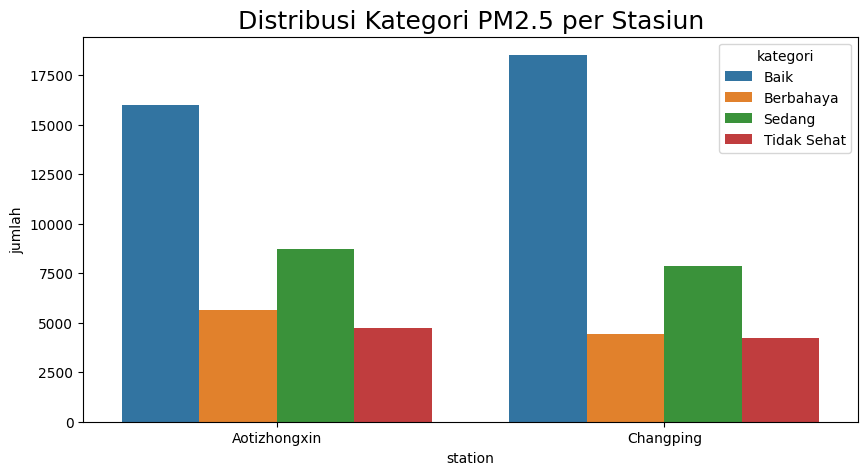

In [169]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=kategori_station_df,
    x="station",
    y="jumlah",
    hue="kategori"
)

plt.title("Distribusi Kategori PM2.5 per Stasiun", fontsize=18)
plt.show()

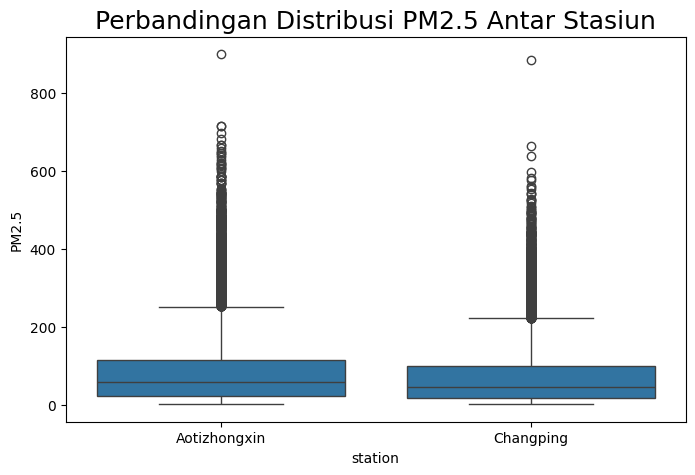

In [170]:
plt.figure(figsize=(8,5))

sns.boxplot(data=main_df, x="station", y="PM2.5")

plt.title("Perbandingan Distribusi PM2.5 Antar Stasiun", fontsize=18)
plt.show()

## Conclusion

- **Conclution pertanyaan 1:**
Berdasarkan hasil analisis, terdapat perbedaan rata-rata konsentrasi PM2.5 antara stasiun Aotizhongxin dan Changping. Salah satu stasiun menunjukkan nilai rata-rata yang lebih tinggi, yang mengindikasikan bahwa wilayah tersebut memiliki tingkat polusi udara yang lebih buruk dibandingkan stasiun lainnya. Perbedaan ini menegaskan bahwa kualitas udara dipengaruhi oleh faktor lokasi, seperti tingkat urbanisasi, kepadatan lalu lintas, serta aktivitas industri di sekitar wilayah pengamatan. Dengan begitu, stasiun dengan nilai PM2.5 tertinggi dapat dikategorikan sebagai area dengan risiko polusi udara yang lebih tinggi dan memerlukan perhatian lebih dalam pengelolaan lingkungan.

- **Conclution pertanyaan 2:**
Hasil analisis menunjukkan bahwa konsentrasi PM2.5 memiliki pola musiman yang jelas sepanjang tahun. Tingkat polusi cenderung meningkat pada akhir tahun, dengan bulan Desember sebagai periode dengan kualitas udara terburuk, sedangkan tingkat polusi terendah terjadi pada pertengahan tahun, khususnya bulan Agustus. Pola ini mengindikasikan bahwa faktor musiman, seperti kondisi cuaca dan suhu, berperan penting dalam mempengaruhi tingkat polusi udara. Oleh karena itu, periode akhir tahun dapat dianggap sebagai waktu dengan risiko polusi tertinggi, sementara pertengahan tahun relatif memiliki kualitas udara yang lebih baik.